# Init

In [1]:
import torch
import numpy as np
import sympy  as sp
import plotly.graph_objects as go

# Nevergrad Imports
import nevergrad as ng

# Symxplorer Specific Imports
from   symxplorer.symbolic_exploration.domains   import ExperimentResult

from   symxplorer.designer_tools.tf_models       import Pole_Zero_TF, Second_Order_BP_TF, cascade_tf
from   symxplorer.designer_tools.visualizer      import Symbolic_Visualizer, Bode_Visualizer
# Optimizer wrapper
from   symxplorer.optimization.symbolic import Nevergrad_Symbolic_Bode_Fitter

s = sp.symbols("s")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype  = torch.double

torch.set_default_dtype(dtype)
torch.set_default_device(device)
print(f'Using device: {device} and dtype: {dtype}')

2025-10-17 23:46:23,240 - SymXplorer.optimizer - Using device: cpu and dtype: torch.float64


Using device: cpu and dtype: torch.float64


# Load the exploration result

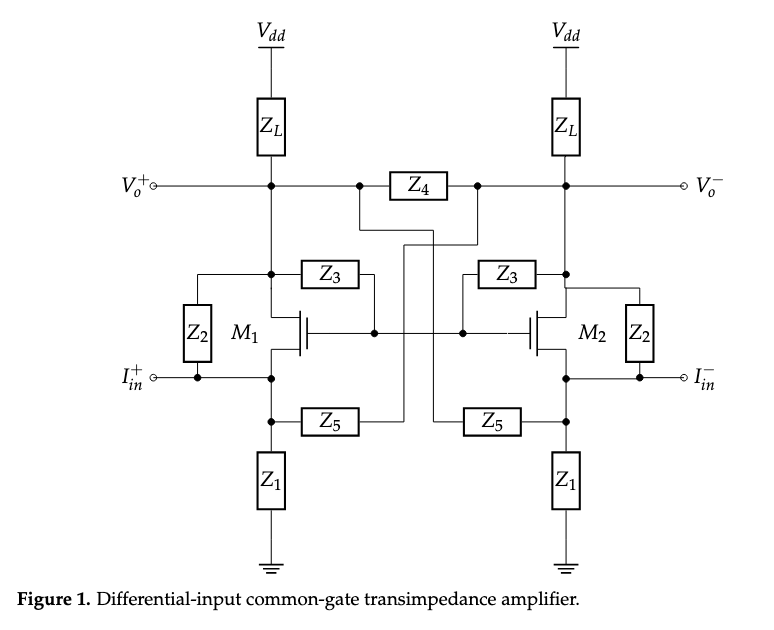

In [2]:
experiment_name = "CG_TIA_Automated_simple"
path_to_pkl = f"Runs/{experiment_name}/results.pkl"
symbolic_experiment_result = ExperimentResult(experiment_name=experiment_name)
symbolic_experiment_result = symbolic_experiment_result.load(path_to_pkl)

# Problem Setup

## Select a topology to size

In [3]:
ALLOWED_Z_CONNECTIONS = "Z1_Z2_ZL"
classifications, tf = symbolic_experiment_result.get_impedance_key(ALLOWED_Z_CONNECTIONS)
print(f"{ALLOWED_Z_CONNECTIONS} - count of tfs {len(classifications)}")
tf

Z1_Z2_ZL - count of tfs 880


(Z_1*Z_2*Z_L*g_m + Z_1*Z_L)/(Z_1*Z_2*g_m + Z_1 + Z_2 + Z_L)

In [4]:
FILTER_TYPE = "BP" # should switch to using enums
classifications_filtered = symbolic_experiment_result.get_filter_types(fTypes=[FILTER_TYPE], zCombos=ALLOWED_Z_CONNECTIONS)
len(classifications_filtered)


6

In [5]:
sel = 0
tf_to_size = classifications_filtered[sel]
print(f"Selected Z-combo is\n{tf_to_size.zCombo}")
print(f"numer order = {tf_to_size.tf_numer_order}\ndenom_order = {tf_to_size.tf_denom_order}\nfilter_id: {tf_to_size.filter_id}")
tf_to_size.transferFunc

Selected Z-combo is
(R_1, R_2, oo, oo, oo, L_L*s/(C_L*L_L*s**2 + 1))
numer order = 1
denom_order = 2
filter_id: 2645


s*(L_L*R_1*R_2*g_m + L_L*R_1)/(L_L*s + R_1*R_2*g_m + R_1 + R_2 + s**2*(C_L*L_L*R_1*R_2*g_m + C_L*L_L*R_1 + C_L*L_L*R_2))

### Filter Parameters

In [6]:
print(f"filter parameters are {tf_to_size.parameters.keys()}")

filter parameters are dict_keys(['Q', 'wo', 'bandwidth', 'K_LP', 'K_HP', 'K_BP', 'Qz', 'Wz'])


In [7]:
# Q
tf_to_size.parameters.get("Q", None)

(sqrt(C_L)*R_1*R_2*g_m + sqrt(C_L)*R_1 + sqrt(C_L)*R_2)/sqrt(L_L)

In [8]:
# WO
tf_to_size.parameters.get("wo", None)

1/(sqrt(C_L)*sqrt(L_L))

In [9]:
# bandwidth
tf_to_size.parameters.get("bandwidth", None)

1/(sqrt(C_L)*(sqrt(C_L)*R_1*R_2*g_m + sqrt(C_L)*R_1 + sqrt(C_L)*R_2))

In [10]:
# K_BP
tf_to_size.parameters.get("K_BP", None)

R_1*R_2*g_m + R_1

### Symbolic Visualization

In [11]:
sym_vis = Symbolic_Visualizer(filter_classification=tf_to_size)
sym_vis.is_defined_numerically()

False

In [12]:
sym_vis.get_parameters()

['C_L', 'L_L', 'R_1', 'R_2', 'g_m']

In [13]:
sym_vis.reset()
sym_vis.set_params(param_str_to_value={
    "R_1" : 1e3,
    "R_2" : 1e3,
    "C_L" : 1e-12,
    "L_L" : 1e-9,
    # "g_m" : 20e-3,
})
sym_vis.params_to_value

{s: 2*I*pi*f, R_1: 1000.0, R_2: 1000.0, C_L: 1e-12, L_L: 1e-09}

In [14]:
magnitude_expr, phase_expr, H_numeric = sym_vis.get_bode_expression()
H_numeric

2*I*pi*f*(0.001*g_m + 1.0e-6)/(-4*pi**2*f**2*(1.0e-15*g_m + 2.0e-18) + 2.0e-9*I*pi*f + 1000000.0*g_m + 2000.0)

In [15]:
sym_vis.get_filter_param()

['K_BP', 'K_HP', 'K_LP', 'Q', 'bandwidth', 'wo']

In [16]:
sym_vis.eval_filter_parameter(param_name="K_BP", num_of_decimals=3)

Cannot numerically evaluate the TF since the design parameters are not resolved. provided {s: 2*I*pi*f, R_1: 1000.0, R_2: 1000.0, C_L: 1e-12, L_L: 1e-09} but need {s, g_m, R_2, C_L, L_L, R_1}


(1000000.0*g_m + 1000.0, nan)

In [ ]:
sym_vis.set_params(param_str_to_value={
    "R_1" : 1e3,
    "R_2" : 1e3,
    "C_L" : 1e-12,
    "L_L" : 1e-9,
    # "g_m" : 20e-3,
})

## Define the target TF

In [17]:
frequencies = torch.logspace(5, 10, 20000)

fc = 1e8
q  = 1
k_bp = 1e3
target_tf_obj = Second_Order_BP_TF(q=q, fc=fc, k_bp=k_bp)
target_tf     = target_tf_obj.get_tf()
# target_tf = cascade_tf(list_of_tfs=[tf1, tf2], dc_gain_multiplier=1)

k_bp_db = 20*np.log10(k_bp)

Calculating Phases: 100%|██████████| 200/200 [00:00<00:00, 342.95it/s]


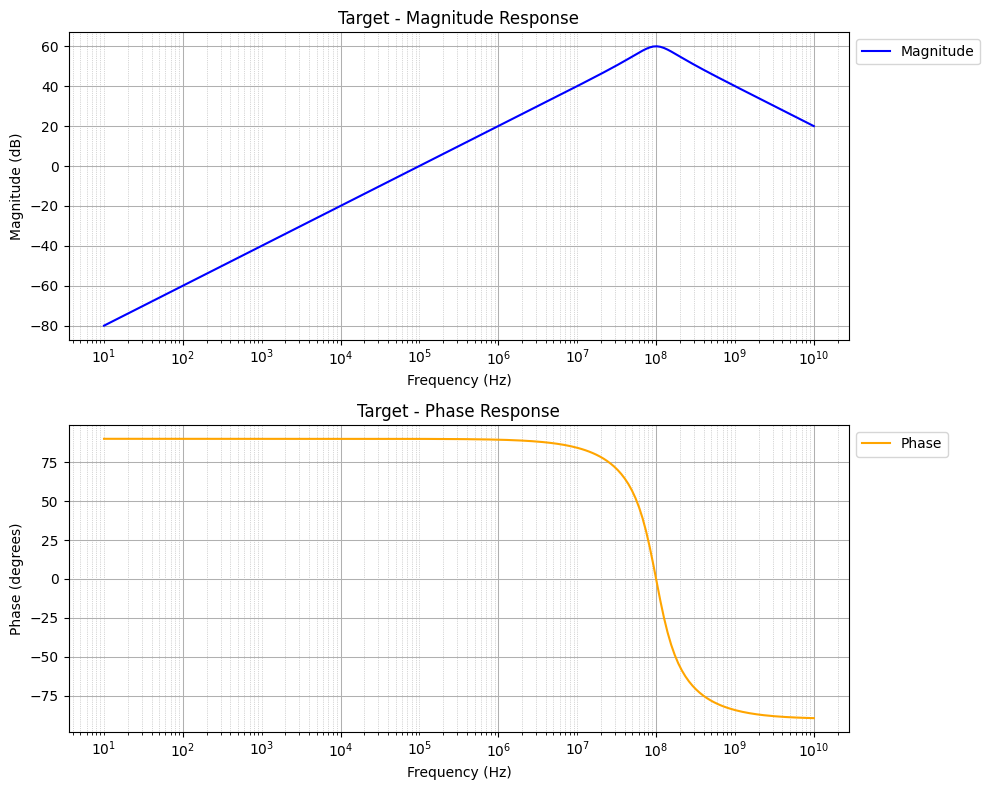

In [18]:
taregt_vis = Symbolic_Visualizer(tf=target_tf)
taregt_vis.visualize(start_freq_order=1, end_freq_order=10, num_of_points=200, title="Target")

In [19]:
# Define range
lower_bound = 1e6
upper_bound = 12e6

# Generate binary mask
weighted_frequencies = torch.where((frequencies >= lower_bound) & (frequencies <= upper_bound), 1, 1)

# Direct Solving via Symbolic Solutions

# Optimizer

In [20]:
print({x for x in ng.optimizers.registry})

{'HSSVMCMA', 'MutDE', 'NGOptSingle9', 'ChainCMAwithRdim', 'NLOPT_LN_COBYLA', 'VoronoiDE', 'Carola13', 'SADiscreteOnePlusOneExp09', 'BAR4', 'NgIoh4', 'Shiwa', 'VastDE', 'MixDeterministicRL', 'ChainDEwithLHS', 'Wiz', 'MetaModelFmin2', 'BOSplit', 'MinRecombiningDiscreteLenglerOnePlusOne', 'TinySPSA', 'FastGAOptimisticNoisyDiscreteOnePlusOne', 'AnisoEMNA', 'SplitSQOPSO', 'HullCenterHullAvgCauchyScrHammersleySearch', 'NaiveTBPSA', 'SqrtBFGSCMA', 'SplitTwoPointsDE', 'Powell', 'CM', 'ChainCMAwithMetaRecenteringsqrt', 'QOScrHammersleySearch', 'TinyLhsDE', 'SqrtMultiBFGSPlus', 'AnisotropicAdaptiveDiscreteOnePlusOne', 'CauchyLHSSearch', 'ImageMetaModel', 'DiscreteLenglerFourthOnePlusOne', 'FSQPCMA', 'OptimisticDiscreteOnePlusOne', 'ChainDEwithMetaTuneRecentering', 'Zero', 'CMandAS2', 'NLOPT_GN_ISRES', 'MicroSQP', 'FCMA', 'NgIoh2', 'TEAvgScrHammersleySearchPlusMiddlePoint', 'ChainPSOwithRsqrt', 'NgIoh14b', 'RF1MetaModel', 'EDA', 'NaiveAnisoEMNA', 'RF1MetaModelE', 'NGO', 'RecES', 'RandRecombiningD

"LogBFGSCMAPlus" optimizer has given the best result so far.

In [21]:
ng.optimizers.registry.get("LogBFGSCMAPlus")

nevergrad.optimization.optimizerlib.LogBFGSCMAPlus

In [22]:
ng_wrapper = Nevergrad_Symbolic_Bode_Fitter(
    tf_to_size=tf_to_size.transferFunc,
    target_tf=target_tf,
    c_range=[1e-12, 1e-9],
    r_range=[1e2, 1e5],
    frequencies=frequencies,
    # freq_weights=weighted_frequencies,
    max_loss=float('inf'),
    loss_norm_method='min-max',
    loss_type="mse",
    optimizer_name="LogBFGSCMAPlus",
    random_seed=42
)

Computing filter parameters for BiQuad:   0%|          | 0/1 [00:00<?, ?filter/s]


In [23]:
ng_wrapper.parameterize(log_scale=False)

({'g_m': Scalar{Cl(1,100,b)}[sigma=Scalar{exp=2.03}]:50.5,
  'R_2': Scalar{Cl(1,1000,b)}[sigma=Scalar{exp=2.03}]:500.5,
  'C_L': Scalar{Cl(1,1000.0000000000001,b)}[sigma=Scalar{exp=2.03}]:500.50000000000006,
  'L_L': Scalar{Cl(1,100,b)}[sigma=Scalar{exp=2.03}]:50.5,
  'R_1': Scalar{Cl(1,1000,b)}[sigma=Scalar{exp=2.03}]:500.5},
 1e-12,
 100.0)

In [24]:
ng_wrapper.create_experiment(budget=5000)
ng_wrapper.optimize(include_mag_loss=False, include_phase_loss=True, render_optimization_trace=True)

Optimizer is set to LogBFGSCMAPlus with budget = 5000


Optimizing:   1%|          | 47/5000 [00:01<01:51, 44.60trial/s]/Users/danialnoorizadeh/.pyenv/versions/myenv/lib/python3.12/site-packages/cma/evolution_strategy.py:2420: InjectionWarning:

orphanated injected solution {'iteration': 1, 'index': 0, 'counter': 0}
                            This could be a bug in the calling order/logics or due to
                            a too small popsize used in `ask()` or when only using
                            `ask(1)` repeatedly. Please check carefully.
                            In case this is desired, the warning can be surpressed with
                            ``warnings.simplefilter("ignore", cma.evolution_strategy.InjectionWarning)``
                            

Optimizing:   1%|          | 58/5000 [00:01<01:57, 41.96trial/s]/Users/danialnoorizadeh/.pyenv/versions/myenv/lib/python3.12/site-packages/cma/evolution_strategy.py:2420: InjectionWarning:

orphanated injected solution {'iteration': 2, 'index': 0, 'counter': 1}
           

True

In [25]:
best_params, loss = ng_wrapper.get_best()
best_params, loss

Optimized x - normalized: {'g_m': 1.0000000059061687, 'R_2': 1.0000000088193102, 'C_L': 1.0000003350979663, 'L_L': 95.99222416083187, 'R_1': 1.0000026989421686}
Optimized x - de-normalized: {'g_m': 1.0000000059061687, 'R_2': 100.00000088193102, 'C_L': 1.0000003350979662e-12, 'L_L': 95.99222416083187, 'R_1': 100.00026989421687}
loss: 522.8710696198715


({'g_m': 1.0000000059061687,
  'R_2': 100.00000088193102,
  'C_L': 1.0000003350979662e-12,
  'L_L': 95.99222416083187,
  'R_1': 100.00026989421687},
 522.8710696198715)

In [26]:
ng_wrapper.plot_solution(best_params)

mag_loss 105.92156246344513, phase_loss 522.8710696198715, max-mag 80.0862808227539


## Plot

In [ ]:
# best_params, loss = ng_wrapper.optimizer_trace[4200]
# best_params = ng_wrapper.denormalize_params(best_params.value)
# best_params, loss

({'g_m': 90.10412328196584,
  'R_2': 24683.391999999996,
  'C_L': 8.390932813437313e-10,
  'L_L': 93.28076171875,
  'R_1': 53041.97530864197},
 1326.4514545159768)

In [31]:
ng_wrapper.plot_solution(best_params)

mag_loss 281.75292823992186, phase_loss 1326.4514545159768, max-mag 65.56047821044922
